In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("C:/Users/User/Desktop/ML 2/ML-assignment/data/kidney_disease.csv")

print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['classification'].value_counts())
df.head()

Shape: (400, 26)

Column names: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Missing values:
 id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

Target distribution:
 classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
data = df.copy()

# Strip whitespace from column names
data.columns = data.columns.str.strip()

# Replace tab/question mark artifacts with NaN
data = data.replace({'\t?': np.nan, '?': np.nan}, regex=False)
data = data.replace(r'^\s*$', np.nan, regex=True)

# Force numeric columns to numeric dtype
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu',
                'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Clean and encode target column
data['classification'] = data['classification'].astype(str).str.strip()
data['classification'] = data['classification'].replace({'ckd\t': 'ckd', 'notckd': 'notckd'})
data['classification'] = data['classification'].map({'ckd': 1, 'notckd': 0})

# Drop rows where target is still NaN
data = data.dropna(subset=['classification'])
y = data['classification'].astype(int)

# Encode categorical features
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in cat_cols:
    data[col] = data[col].astype(str).str.strip().str.lower()
    data[col] = data[col].replace({'nan': np.nan, 'none': np.nan, '': np.nan})

le = LabelEncoder()
for col in cat_cols:
    non_null = data[col].dropna()
    le.fit(non_null)
    data[col] = data[col].map(lambda x: le.transform([x])[0]
                               if pd.notna(x) and x in le.classes_
                               else np.nan)

# Drop id and target from features
X = data.drop(columns=['id', 'classification'], errors='ignore')

# Impute all remaining NaN with column mean
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Preprocessing complete!")
print("X shape:", X_imputed.shape)
print("y shape:", y.shape)
print("Class counts:\n", y.value_counts())

Preprocessing complete!
X shape: (400, 24)
y shape: (400,)
Class counts:
 classification
1    250
0    150
Name: count, dtype: int64


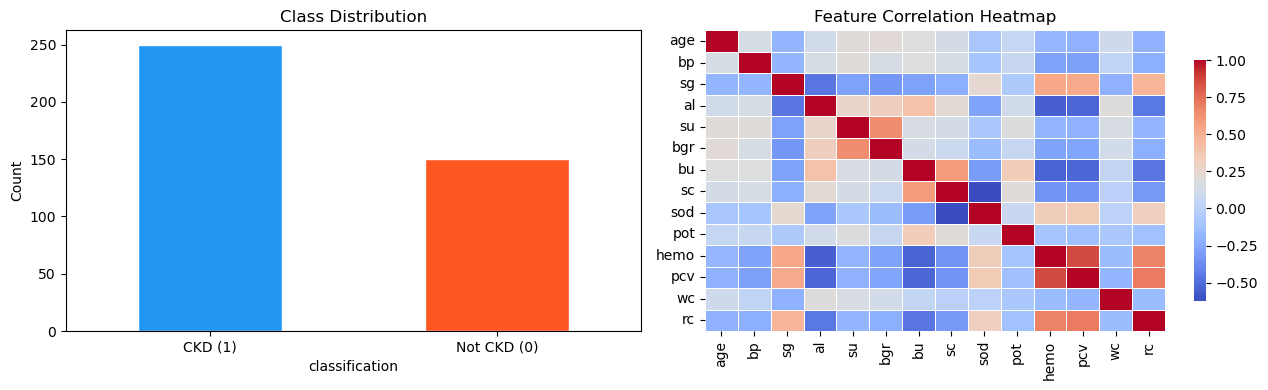

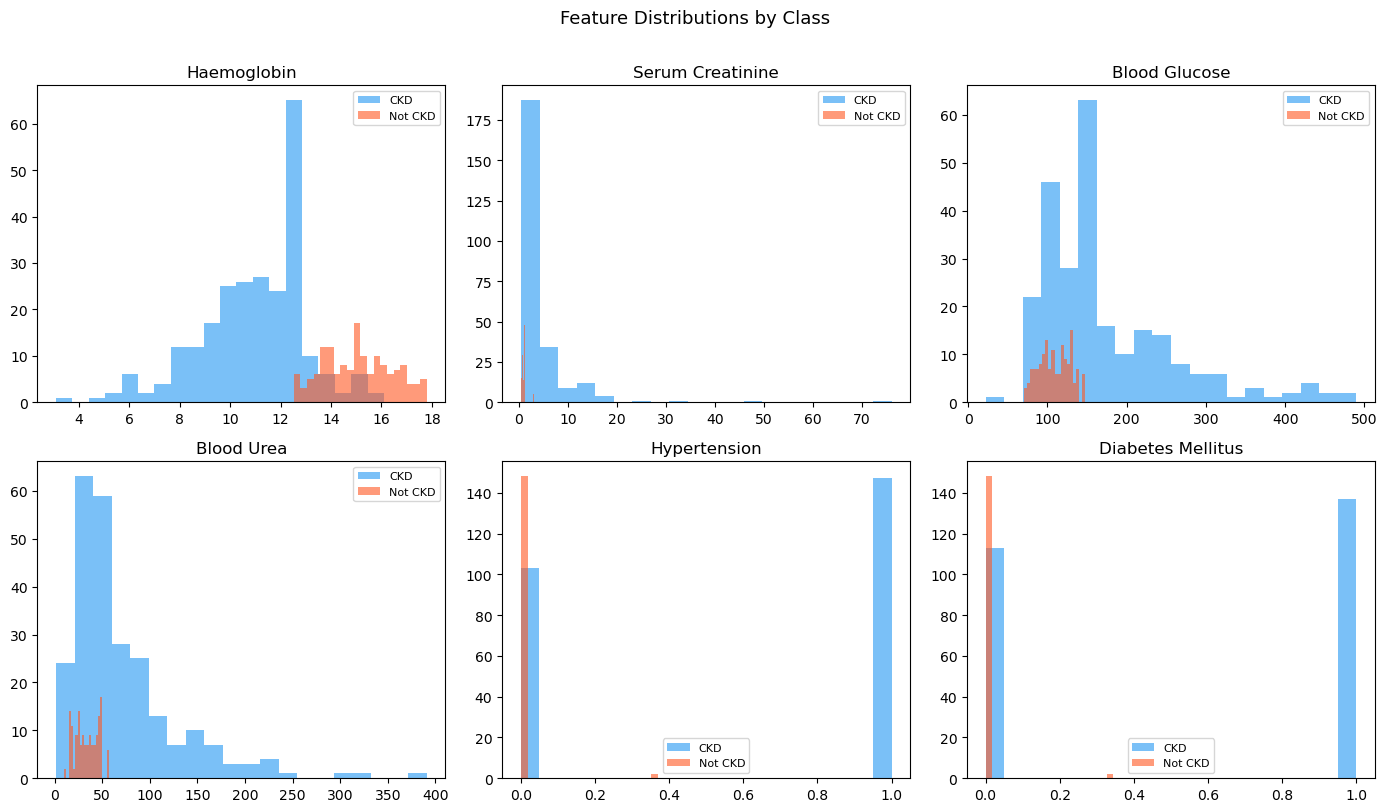

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
y.value_counts().plot(kind='bar', ax=axes[0],
                      color=['#2196F3', '#FF5722'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['CKD (1)', 'Not CKD (0)'], rotation=0)
axes[0].set_ylabel('Count')

# Correlation heatmap
corr = X_imputed[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=False,
            linewidths=0.4, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# Feature distributions by class
key_features = ['hemo', 'sc', 'bgr', 'bu', 'htn', 'dm']
feature_labels = ['Haemoglobin', 'Serum Creatinine', 'Blood Glucose',
                  'Blood Urea', 'Hypertension', 'Diabetes Mellitus']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    ax = axes[i // 3][i % 3]
    ax.hist(X_imputed[feat][y == 1], bins=20, alpha=0.6,
            color='#2196F3', label='CKD')
    ax.hist(X_imputed[feat][y == 0], bins=20, alpha=0.6,
            color='#FF5722', label='Not CKD')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 320
Test samples     : 80
Features         : 24


In [8]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)
y_prob_default = dt_default.predict_proba(X_test)[:, 1]

print("=== Default Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_default):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default,
                            target_names=['Not CKD', 'CKD']))

=== Default Decision Tree ===
Accuracy : 0.9750
ROC-AUC  : 0.9800

Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [9]:
param_grid = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest Parameters :", grid_search.best_params_)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy : 0.9844


In [10]:
best_dt = grid_search.best_estimator_

y_pred_best = best_dt.predict(X_test)
y_prob_best = best_dt.predict_proba(X_test)[:, 1]

print("=== Tuned Decision Tree ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['Not CKD', 'CKD']))

=== Tuned Decision Tree ===
Accuracy  : 0.9750
Precision : 0.9800
Recall    : 0.9800
F1 Score  : 0.9800
ROC-AUC   : 0.9893

Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.97      0.97      0.97        30
         CKD       0.98      0.98      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



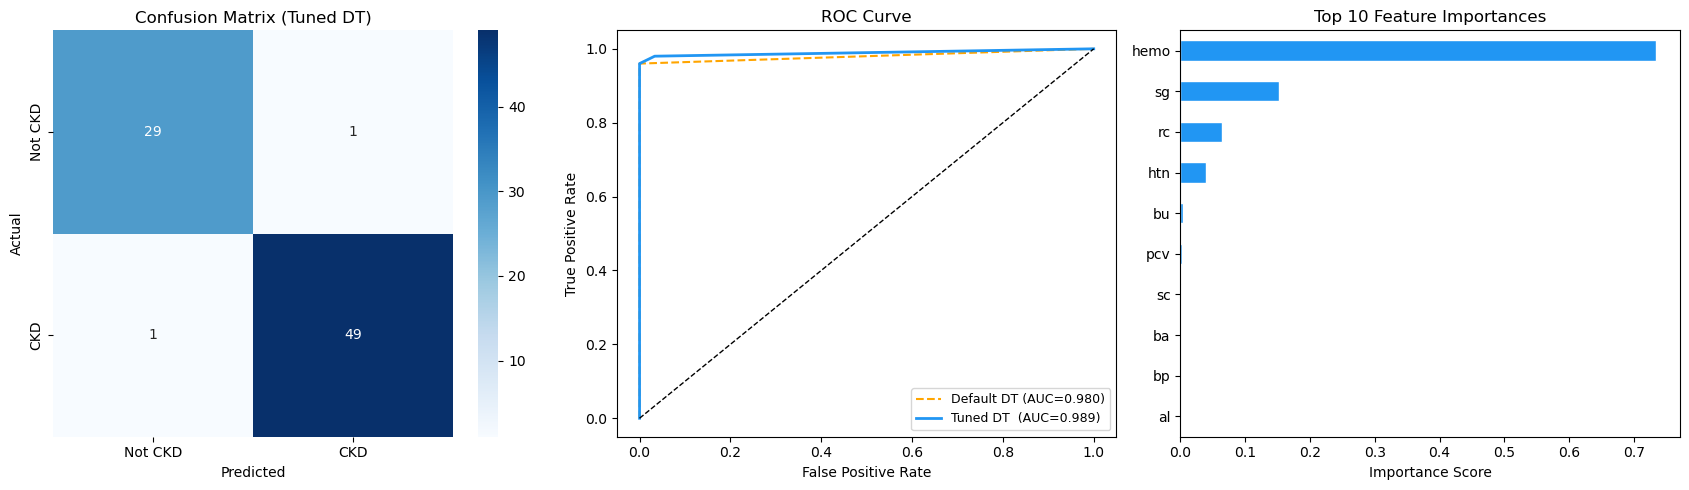

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
axes[0].set_title('Confusion Matrix (Tuned DT)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- ROC Curve ---
fpr_d, tpr_d, _ = roc_curve(y_test, y_prob_default)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr_d, tpr_d, color='orange', lw=1.5, linestyle='--',
             label=f'Default DT (AUC={roc_auc_score(y_test, y_prob_default):.3f})')
axes[1].plot(fpr_b, tpr_b, color='#2196F3', lw=2,
             label=f'Tuned DT  (AUC={roc_auc_score(y_test, y_prob_best):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# --- Feature Importance ---
importances = pd.Series(best_dt.feature_importances_,
                        index=X_imputed.columns).sort_values(ascending=True)
top10 = importances.tail(10)
top10.plot(kind='barh', ax=axes[2], color='#2196F3', edgecolor='white')
axes[2].set_title('Top 10 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('dt_evaluation_plots.png', dpi=150)
plt.show()

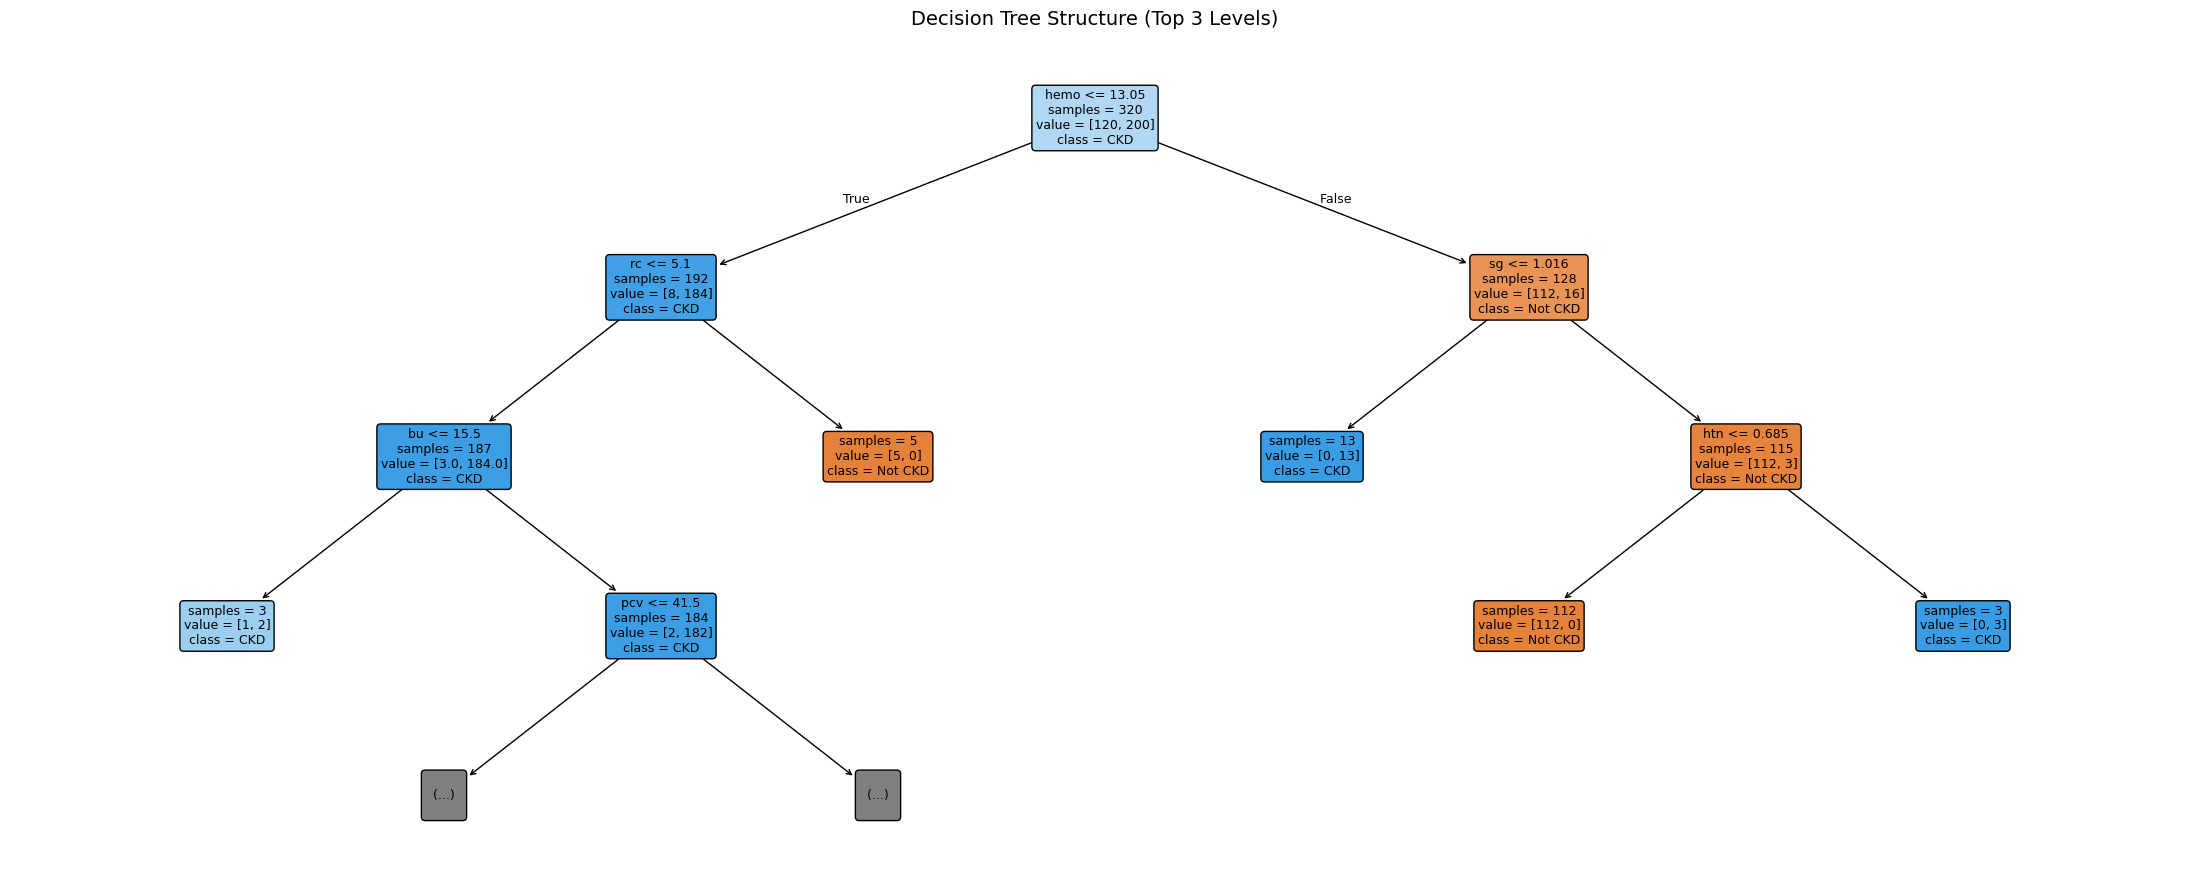

|--- hemo <= 13.05
|   |--- rc <= 5.10
|   |   |--- bu <= 15.50
|   |   |   |--- class: 1
|   |   |--- bu >  15.50
|   |   |   |--- pcv <= 41.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- pcv >  41.50
|   |   |   |   |--- class: 1
|   |--- rc >  5.10
|   |   |--- class: 0
|--- hemo >  13.05
|   |--- sg <= 1.02
|   |   |--- class: 1
|   |--- sg >  1.02
|   |   |--- htn <= 0.68
|   |   |   |--- class: 0
|   |   |--- htn >  0.68
|   |   |   |--- class: 1



In [12]:
plt.figure(figsize=(22, 9))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=list(X_imputed.columns),
    class_names=['Not CKD', 'CKD'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

# Text representation
print(export_text(best_dt,
                  feature_names=list(X_imputed.columns),
                  max_depth=3))